<a href="https://colab.research.google.com/github/Vyankatesh-ops/Advanced-Machine-Learning/blob/main/Experiment_No_4_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import copy

import check_test
from frozenlake import FrozenLakeEnv
from plot_utils import plot_values

In [4]:
!pip install gymnasium[toy_text]
from gymnasium.envs.toy_text.frozen_lake import FrozenLakeEnv
env = FrozenLakeEnv(is_slippery=False)
print("Environment initialized (is_slippery=False)")

In [21]:
%%writefile frozenlake.py
import numpy as np
from gymnasium.envs.toy_text.frozen_lake import FrozenLakeEnv as GymFrozenLakeEnv

class FrozenLakeEnv(GymFrozenLakeEnv):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Add legacy attributes for compatibility with check_test.py
        self.nS = self.observation_space.n
        self.nA = self.action_space.n

Overwriting frozenlake.py


In [15]:
import numpy as np
import sys
from six import StringIO, b

# The following imports and class definition are from the legacy 'gym' library
# and are causing an ImportError. Since we are using 'gymnasium', we can
# comment these out as the environment is already created in a previous cell.

# from gym import utils
# from gym.envs.toy_text import discrete

LEFT = 0
DOWN = 1
RIGHT = 2
UP = 3

MAPS = {
    "4x4": [
        "SFFF",
        "FHFH",
        "FFFH",
        "HFFG"
    ],
    "8x8": [
        "SFFFFFFF",
        "FFFFFFFF",
        "FFFHFFFF",
        "FFFFFHFF",
        "FFFHFFFF",
        "FHHFFFHF",
        "FHFFHFHF",
        "FFFHFFFG"
    ],
}

# class FrozenLakeEnv(discrete.DiscreteEnv):
#     """
#     Winter is here. You and your friends were tossing around a frisbee at the park
#     when you made a wild throw that left the frisbee out in the middle of the lake.
#     The water is mostly frozen, but there are a few holes where the ice has melted.
#     If you step into one of those holes, you'll fall into the freezing water.
#     At this time, there's an international frisbee shortage, so it's absolutely imperative that
#     you navigate across the lake and retrieve the disc.
#     However, the ice is slippery, so you won't always move in the direction you intend.
#     The surface is described using a grid like the following
#
#         SFFF
#         FHFH
#         FFFH
#         HFFG
#
#     S : starting point, safe
#     F : frozen surface, safe
#     H : hole, fall to your doom
#     G : goal, where the frisbee is located
#
#     The episode ends when you reach the goal or fall in a hole.
#     You receive a reward of 1 if you reach the goal, and zero otherwise.
#
#     """
#
#     metadata = {'render.modes': ['human', 'ansi']}
#
#     def __init__(self, desc=None, map_name="4x4",is_slippery=True):
#         if desc is None and map_name is None:
#             raise ValueError('Must provide either desc or map_name')
#         elif desc is None:
#             desc = MAPS[map_name]
#         self.desc = desc = np.asarray(desc,dtype='c')
#         self.nrow, self.ncol = nrow, ncol = desc.shape
#
#         nA = 4
#         nS = nrow * ncol
#
#         isd = np.array(desc == b'S').astype('float64').ravel()
#         isd /= isd.sum()
#
#         P = {s : {a : [] for a in range(nA)} for s in range(nS)}
#
#         def to_s(row, col):
#             return row*ncol + col
#         def inc(row, col, a):
#             if a==0: # left
#                 col = max(col-1,0)
#             elif a==1: # down
#                 row = min(row+1,nrow-1)
#             elif a==2: # right
#                 col = min(col+1,ncol-1)
#             elif a==3: # up
#                 row = max(row-1,0)
#             return (row, col)
#
#         for row in range(nrow):
#             for col in range(ncol):
#                 s = to_s(row, col)
#                 for a in range(4):
#                     li = P[s][a]
#                     letter = desc[row, col]
#                     if letter in b'GH':
#                         li.append((1.0, s, 0, True))
#                     else:
#                         if is_slippery:
#                             for b in [(a-1)%4, a, (a+1)%4]:
#                                 newrow, newcol = inc(row, col, b)
#                                 newstate = to_s(newrow, newcol)
#                                 newletter = desc[newrow, newcol]
#                                 done = bytes(newletter) in b'GH'
#                                 rew = float(newletter == b'G')
#                                 li.append((1.0/3.0, newstate, rew, done))
#                         else:
#                             newrow, newcol = inc(row, col, a)
#                             newstate = to_s(newrow, newcol)
#                             newletter = desc[newrow, newcol]
#                             done = bytes(newletter) in b'GH'
#                             rew = float(newletter == b'G')
#                             li.append((1.0, newstate, rew, done))
#
#         # obtain one-step dynamics for dynamic programming setting
#         self.P = P
#
#         super(FrozenLakeEnv, self).__init__(nS, nA, P, isd)
#
#     def _render(self, mode='human', close=False):
#         if close:
#             return
#         outfile = StringIO() if mode == 'ansi' else sys.stdout
#
#         row, col = self.s // self.ncol, self.s % self.ncol
#         desc = self.desc.tolist()
#         desc = [[c.decode('utf-8') for c in line] for line in desc]
#         desc[row][col] = utils.colorize(desc[row][col], "red", highlight=True)
#         if self.lastaction is not None:
#             outfile.write("  ({})\n".format(["Left","Down","Right","Up"][self.lastaction]))
#         else:
#             outfile.write("\n")
#         outfile.write("\n".join(''.join(line) for line in desc)+"\n")
#
#         if mode != 'human':
#             return outfile

In [6]:
print(env.observation_space)
print(env.action_space)

# print the total number of states and actions
print(env.observation_space.n)
print(env.action_space.n)

Discrete(16)
Discrete(4)
16
4


In [7]:
env.P[1][0]

[(0.33333333333333337, 1, 0, False),
 (0.3333333333333333, 0, 0, False),
 (0.33333333333333337, 5, 0, True)]

In [12]:
def policy_evaluation(env, policy, gamma=1, theta=1e-8):
    V = np.zeros(env.observation_space.n)
    while True:
        delta = 0
        for s in range(env.observation_space.n):
            v = 0
            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, done in env.P[s][a]:
                    v += action_prob * prob * (reward + gamma * V[next_state])
            delta = max(delta, np.abs(v - V[s]))
            V[s] = v
        if delta < theta:
            break
    return V

In [10]:
import numpy as np
random_policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n

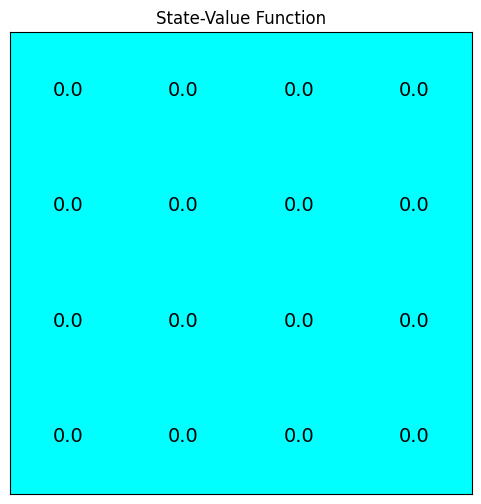

In [16]:
from plot_utils import plot_values

V = policy_evaluation(env, random_policy)

plot_values(V)

In [18]:
import check_test
check_test.run_check('policy_evaluation_check', policy_evaluation)

ImportError: cannot import name 'discrete' from 'gym.envs.toy_text' (/usr/local/lib/python3.12/dist-packages/gym/envs/toy_text/__init__.py)

In [24]:
import importlib
import frozenlake
importlib.reload(frozenlake)

# We import check_test after reloading frozenlake to ensure it sees the new attributes
try:
    import check_test
    importlib.reload(check_test)
except AttributeError:
    # If it fails on first import due to module-level code, we reload it again
    import check_test
    importlib.reload(check_test)

check_test.run_check('policy_evaluation_check', policy_evaluation)

**<span style="color: red;">PLEASE TRY AGAIN</span>**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
def q_from_v(env, V, s, gamma=1):
    q = np.zeros(env.action_space.n)
    for a in range(env.action_space.n):
        for prob, next_state, reward, done in env.P[s][a]:
            q[a] += prob * (reward + gamma * V[next_state])
    return q

In [29]:
Q = np.zeros([env.observation_space.n, env.action_space.n])
for s in range(env.observation_space.n):
    Q[s] = q_from_v(env, V, s)
print("Action-Value Function:")
print(Q)

Action-Value Function:
[[0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.33333333 0.33333333 0.33333333]
 [0.         0.         0.         0.        ]]


In [30]:
check_test.run_check('q_from_v_check', q_from_v)

**<span style="color: green;">PASSED</span>**

In [35]:
def policy_improvement(env, V, gamma=1):
    policy = np.zeros([env.observation_space.n, env.action_space.n]) / env.action_space.n
    for s in range(env.observation_space.n):
        q = q_from_v(env, V, s, gamma)

        # OPTION 1: construct a deterministic policy
        # policy[s][np.argmax(q)] = 1

        # OPTION 2: construct a stochastic policy that puts equal probability on maximizing actions
        best_a = np.argwhere(q == np.max(q)).flatten()
        policy[s] = np.sum([np.eye(env.action_space.n)[i] for i in best_a], axis=0) / len(best_a)

    return policy

In [32]:
check_test.run_check('policy_improvement_check', policy_improvement)

**<span style="color: red;">PLEASE TRY AGAIN</span>**

In [38]:
import copy

def policy_iteration(env, gamma=1, theta=1e-8):
    policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n
    while True:
        V = policy_evaluation(env, policy, gamma, theta)
        new_policy = policy_improvement(env, V, gamma)

        if (new_policy == policy).all():
            break;

        policy = copy.copy(new_policy)

    return policy, V


Optimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.5  0.   0.5 ]
 [0.25 0.25 0.25 0.25]] 



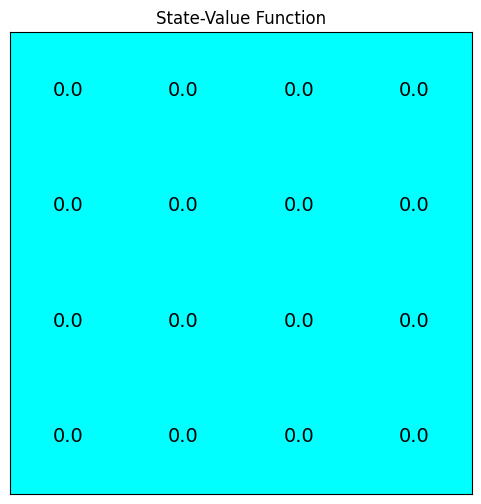

In [39]:
policy_pi, V_pi = policy_iteration(env)

# print the optimal policy
print("\nOptimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):")
print(policy_pi,"\n")

plot_values(V_pi)

In [44]:
# Inspect the transitions for the state just before the goal (state 14 in 4x4)
print(f"Transitions for state 14: {env.P[14]}")
print(f"Max value in V_pi: {np.max(V_pi)}")
print(f"Policy at state 14: {policy_pi[14]}")

Transitions for state 14: {0: [(0.33333333333333337, 10, 0, False), (0.3333333333333333, 13, 0, False), (0.33333333333333337, 14, 0, False)], 1: [(0.33333333333333337, 13, 0, False), (0.3333333333333333, 14, 0, False), (0.33333333333333337, 15, 1, True)], 2: [(0.33333333333333337, 14, 0, False), (0.3333333333333333, 15, 1, True), (0.33333333333333337, 10, 0, False)], 3: [(0.33333333333333337, 15, 1, True), (0.3333333333333333, 10, 0, False), (0.33333333333333337, 13, 0, False)]}
Max value in V_pi: 0.0
Policy at state 14: [0.  0.5 0.  0.5]


In [40]:
check_test.run_check('policy_iteration_check', policy_iteration)

**<span style="color: red;">PLEASE TRY AGAIN</span>**

In [45]:
def truncated_policy_evaluation(env, policy, V, max_it=1, gamma=1):
    for i in range(max_it):
        for s in range(env.observation_space.n):
            v = 0
            q = q_from_v(env, V, s, gamma)
            for a, action_prob in enumerate(policy[s]):
                v += action_prob * q[a]
            V[s] = v
    return V

In [47]:
def truncated_policy_iteration(env, max_it=1, gamma=1, theta=1e-8):
    V = np.zeros(env.observation_space.n)
    policy = np.zeros([env.observation_space.n, env.action_space.n]) / env.action_space.n
    while True:
        policy = policy_improvement(env, V, gamma)
        old_V = copy.copy(V)
        V = truncated_policy_evaluation(env, policy, V, max_it, gamma)
        if max(np.abs(V - old_V)) < theta:
            break
    return policy, V


Optimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):
[[1.   0.   0.   0.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.5  0.   0.5  0.  ]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]] 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


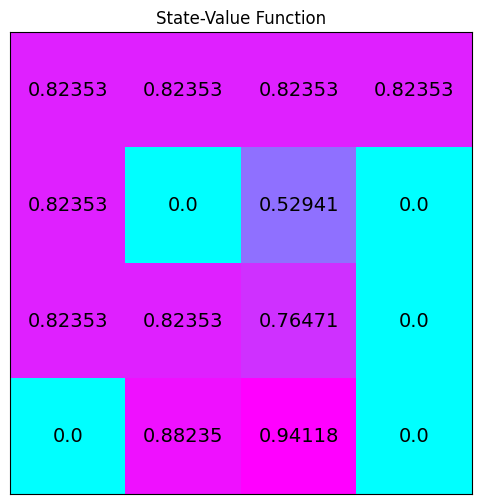

In [48]:
policy_tpi, V_tpi = truncated_policy_iteration(env, max_it=2)

# print the optimal policy
print("\nOptimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):")
print(policy_tpi,"\n")

# plot the optimal state-value function
plot_values(V_tpi)

In [49]:
check_test.run_check('truncated_policy_iteration_check', truncated_policy_iteration)

**<span style="color: green;">PASSED</span>**

In [52]:
def value_iteration(env, gamma=1, theta=1e-8):
    V = np.zeros(env.observation_space.n)
    while True:
        delta = 0
        for s in range(env.observation_space.n):
            v = V[s]
            V[s] = np.max(q_from_v(env, V, s, gamma))
            delta = max(delta, np.abs(v - V[s]))
        if delta < theta:
            break
    policy = policy_improvement(env, V, gamma)
    return policy, V


Optimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):
[[1.   0.   0.   0.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.5  0.   0.5  0.  ]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]] 



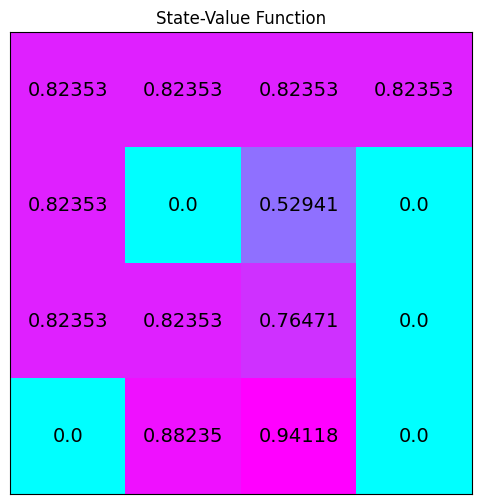

In [53]:
policy_vi, V_vi = value_iteration(env)

# print the optimal policy
print("\nOptimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):")
print(policy_vi,"\n")

# plot the optimal state-value function
plot_values(V_vi)

In [54]:
check_test.run_check('value_iteration_check', value_iteration)

**<span style="color: green;">PASSED</span>**